Orekit environment successfully loaded!

Propagating for 24.0 hours (Gravity 10x10, Drag, SRP, 3rd Body)...

  RESULTS AFTER 24 HOURS OF PERTURBED PROPAGATION
Initial Semi-major axis: 6678.137 km
Final Semi-major axis:   6673.113 km
--> Altitude Decay (SMA): 5024.1 meters lost due to Drag
--------------------------------------------------------
Initial Inclination: 50.00000 deg
Final Inclination:   49.98181 deg
--------------------------------------------------------
Initial RAAN:        0.000 deg
Final RAAN:          -5.496 deg
--> Ascending Node Drift caused by J2 effect

Generating 3D plot...


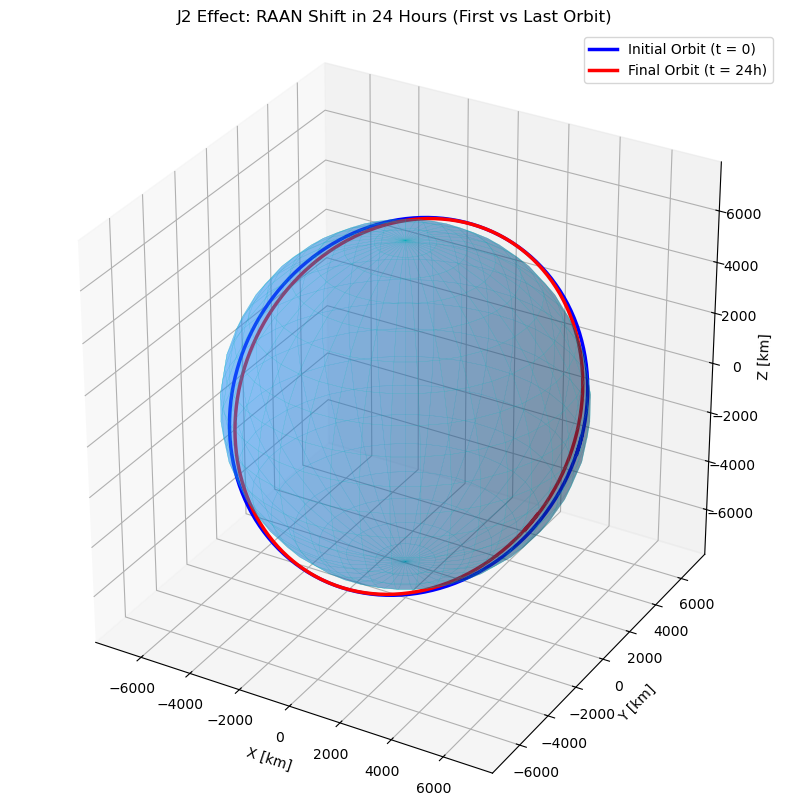

In [1]:
import math
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main') 

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

# Imports for Perturbations 
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

print("Orekit environment successfully loaded!")

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000() # J2000 / ECI
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True) # ECEF

# Earth body creation (for atmosphere and SRP)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)

mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. ORBIT CREATION (LEO at 300 km)
# ==========================================
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + 300e3  # 300 km altitude (meters)
e = 0.001
i = math.radians(50.0)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0) # Adding 850 kg of mass (as in GMAT)

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())

# Explicit cast from Java Object to Double Array for Python
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

# ==========================================
# 5. ADDING ALL PERTURBATIONS
# ==========================================
# A) Earth Gravity (10x10 Spherical harmonics for J2, J3, etc.)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# B) Third-Body (Sun and Moon)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# C) Atmospheric Drag (Harris-Priester Model)
atmosphere = HarrisPriester(sun, earth_shape)
# DragArea = 15 m^2, Cd = 2.2 (Same parameters as GMAT)
drag = DragForce(atmosphere, IsotropicDrag(15.0, 2.2))
propagator.addForceModel(drag)

# D) Solar Radiation Pressure (SRP)
# SRPArea = 1 m^2, Cr = 1.8
srp = SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(1.0, 1.8))
propagator.addForceModel(srp)

# ==========================================
# 6. 24-HOUR PROPAGATION
# ==========================================
duration = 24.0 * 3600.0  # 24 hours in seconds
final_date = initial_date.shiftedBy(duration)

print(f"\nPropagating for {duration/3600} hours (Gravity 10x10, Drag, SRP, 3rd Body)...")
ephemeris_generator = propagator.getEphemerisGenerator()
final_state = propagator.propagate(final_date)
final_orbit = final_state.getOrbit()

# ==========================================
# 7. RESULTS: DECAY AND VARIATIONS
# ==========================================
# Translate the generic final orbit into a Keplerian orbit
final_kep_orbit = KeplerianOrbit(final_orbit)
a_fin = final_kep_orbit.getA()
i_fin = math.degrees(final_kep_orbit.getI())
raan_fin = math.degrees(final_kep_orbit.getRightAscensionOfAscendingNode())

print("\n========================================================")
print("  RESULTS AFTER 24 HOURS OF PERTURBED PROPAGATION")
print("========================================================")
print(f"Initial Semi-major axis: {a/1000:.3f} km")
print(f"Final Semi-major axis:   {a_fin/1000:.3f} km")
print(f"--> Altitude Decay (SMA): {((a - a_fin)/1000)*1000:.1f} meters lost due to Drag")
print("--------------------------------------------------------")
print(f"Initial Inclination: {math.degrees(i):.5f} deg")
print(f"Final Inclination:   {i_fin:.5f} deg")
print("--------------------------------------------------------")
print(f"Initial RAAN:        {math.degrees(raan):.3f} deg")
print(f"Final RAAN:          {raan_fin:.3f} deg")
print(f"--> Ascending Node Drift caused by J2 effect")
print("========================================================")

# ==========================================
# 8. 3D VISUALIZATION (INITIAL vs FINAL)
# ==========================================
print("\nGenerating 3D plot...")
ephemeris = ephemeris_generator.getGeneratedEphemeris()

# The period of a 300km LEO orbit is roughly 90 minutes (5400 seconds).
# We use 5500 to ensure the circle is visually closed.
periodo_orbitale = 5500.0

# 1. Extract Initial Orbit points (t=0 to t=90 min)
times_init = np.linspace(0, periodo_orbitale, 150)
x_init, y_init, z_init = [], [], []
for t in times_init:
    current_date = initial_date.shiftedBy(float(t))
    pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
    x_init.append(pos.getX() / 1000.0)
    y_init.append(pos.getY() / 1000.0)
    z_init.append(pos.getZ() / 1000.0)

# 2. Extract Final Orbit points (t=24h - 90 min to t=24h)
times_final = np.linspace(duration - periodo_orbitale, duration, 150)
x_fin, y_fin, z_fin = [], [], []
for t in times_final:
    current_date = initial_date.shiftedBy(float(t))
    pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
    x_fin.append(pos.getX() / 1000.0)
    y_fin.append(pos.getY() / 1000.0)
    z_fin.append(pos.getZ() / 1000.0)

# Plot Creation
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw the Earth with a light wireframe to give a sense of volume
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Plot the two single separate orbits
ax.plot(x_init, y_init, z_init, color='blue', linewidth=2.5, label='Initial Orbit (t = 0)')
ax.plot(x_fin, y_fin, z_fin, color='red', linewidth=2.5, label='Final Orbit (t = 24h)')

# Perfect axes setup (fundamental to maintain sphericity)
lim = R_E_km + 1500
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) # This command prevents the Earth from looking like an oval

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('J2 Effect: RAAN Shift in 24 Hours (First vs Last Orbit)')
ax.legend(loc='upper right')

plt.show()